# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

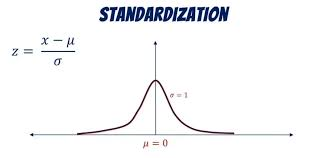


In [3]:
# GitHub Repository
!git clone https://github.com/Akinloye3264/PCA_Formative.git
%cd PCA_Formative
!ls

Cloning into 'PCA_Formative'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 2), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 1.07 MiB | 17.41 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/PCA_Formative/PCA_Formative/PCA_Formative
 API_16_DS2_en_csv_v2_264259.csv
'BSE Group Assignments _ Task Sheet_Mathematics_for_Machine_Learning_Formative_2_Group30 - 1.pdf'
'PCA_Formative_1[Peer_Pair_30].ipynb'


In [4]:
# Step 1: Load and Standardize the data
import numpy as np

filename = "API_16_DS2_en_csv_v2_264259.csv"
with open(filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()

for i, line in enumerate(lines[:10]):
    print(f"Row {i}: {line[:100]}")

Row 0: ﻿"Data Source","World Development Indicators",

Row 1: 

Row 2: "Last Updated Date","2026-04-08",

Row 3: 

Row 4: "Country Name","Country Code","Indicator Name","Indicator Code","1960","1961","1962","1963","1964","
Row 5: "Aruba","ABW","Urban population (% of total population)","SP.URB.TOTL.IN.ZS","59.0236701687155","59.
Row 6: "Aruba","ABW","Urban population","SP.URB.TOTL","32417","32831","33348","33878","34412","34958","3549
Row 7: "Aruba","ABW","Urban population growth (annual %)","SP.URB.GROW","","1.26902144408506","1.5624609553
Row 8: "Aruba","ABW","Mortality caused by road traffic injury (per 100,000 population)","SH.STA.TRAF.P5",""
Row 9: "Aruba","ABW","Population in urban agglomerations of more than 1 million (% of total population)","E


In [5]:
# Parse with numpy's genfromtxt
data = np.genfromtxt(
    filename,
    delimiter='","',
    skip_header=4,
    dtype=str,
    encoding='utf-8'
)
print("Shape:", data.shape)
print(data[0, :6])
print(data[1, :6])

Shape: (4523, 70)
['"Country Name' 'Country Code' 'Indicator Name' 'Indicator Code' '1960'
 '1961']
['"Aruba' 'ABW' 'Urban population (% of total population)'
 'SP.URB.TOTL.IN.ZS' '59.0236701687155' '59.0727998569268']


In [6]:

strip_quotes = np.vectorize(lambda x: x.strip().strip('"').strip("'"))
data = strip_quotes(data)

headers = data[0]
raw_data = data[1:]

indicator_code = "SP.URB.TOTL.IN.ZS"
mask = raw_data[:, 3] == indicator_code
selected = raw_data[mask]
country_names = selected[:, 0]
print("Countries selected:", selected.shape[0])

def safe_float(x):
    try:
        return float(x)
    except (ValueError, TypeError):
        return np.nan

numeric_data = np.vectorize(safe_float)(selected[:, 4:]).astype(float)

valid_cols = ~np.all(np.isnan(numeric_data), axis=0)
numeric_data = numeric_data[:, valid_cols]

min_valid = int(0.8 * numeric_data.shape[1])
row_mask = np.sum(~np.isnan(numeric_data), axis=1) >= min_valid
numeric_data = numeric_data[row_mask]
country_names = country_names[row_mask]
print("Countries kept after completeness filter:", numeric_data.shape[0])

col_means = np.nanmean(numeric_data, axis=0)
nan_idx = np.where(np.isnan(numeric_data))
numeric_data[nan_idx] = np.take(col_means, nan_idx[1])
print("Missing values remaining:", np.sum(np.isnan(numeric_data)))

means = np.mean(numeric_data, axis=0)
stds = np.std(numeric_data, axis=0)
stds[stds == 0] = 1
standardized_data = (numeric_data - means) / stds

print("Standardized data shape:", standardized_data.shape)
print("Mean per feature (~0):", np.round(standardized_data.mean(axis=0)[:5], 4))
print("Std per feature  (~1):", np.round(standardized_data.std(axis=0)[:5], 4))
standardized_data[:5]

Countries selected: 266
Countries kept after completeness filter: 265
Missing values remaining: 0
Standardized data shape: (265, 65)
Mean per feature (~0): [-0. -0.  0. -0. -0.]
Std per feature  (~1): [1. 1. 1. 1. 1.]


array([[ 9.65331723e-01,  9.43336167e-01,  9.26584757e-01,
         9.12276890e-01,  8.99341845e-01,  8.89510726e-01,
         8.81538199e-01,  8.74550287e-01,  8.69244212e-01,
         8.65184773e-01,  8.62303645e-01,  8.59317159e-01,
         8.55652922e-01,  8.52801015e-01,  8.50340813e-01,
         8.46368410e-01,  8.41212901e-01,  8.35018728e-01,
         8.27164615e-01,  8.16621050e-01,  8.01994813e-01,
         7.84663486e-01,  7.65596105e-01,  7.45021383e-01,
         7.23351430e-01,  7.02058202e-01,  6.80496640e-01,
         6.58002142e-01,  6.36594115e-01,  6.16911591e-01,
         6.00070409e-01,  5.83179624e-01,  5.70717176e-01,
         5.59108705e-01,  5.47712727e-01,  5.36545029e-01,
         5.24550823e-01,  5.11603051e-01,  4.99668164e-01,
         4.87505425e-01,  4.74838955e-01,  4.61690948e-01,
         4.46555402e-01,  4.29528023e-01,  4.11067669e-01,
         3.91477294e-01,  3.70954706e-01,  3.49779440e-01,
         3.28193388e-01,  3.06833299e-01,  2.86626453e-0

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [7]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data.T)
print("Covariance matrix shape:", cov_matrix.shape)
print(cov_matrix)

Covariance matrix shape: (65, 65)
[[1.00378788 1.00360336 1.0029349  ... 0.78839029 0.78463659 0.78068005]
 [1.00360336 1.00378788 1.00351756 ... 0.79081345 0.78706708 0.78311564]
 [1.0029349  1.00351756 1.00378788 ... 0.79297397 0.78923819 0.78529369]
 ...
 [0.78839029 0.79081345 0.79297397 ... 1.00378788 1.00371848 1.00353829]
 [0.78463659 0.78706708 0.78923819 ... 1.00371848 1.00378788 1.00372931]
 [0.78068005 0.78311564 0.78529369 ... 1.00353829 1.00372931 1.00378788]]


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [8]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)
print("First 5 eigenvalues:", eigenvalues[:10])

Eigenvalues shape: (65,)
Eigenvectors shape: (65, 65)
First 5 eigenvalues: [6.13526053e+01 3.10825722e+00 5.20720460e-01 1.41883447e-01
 5.04083466e-02 3.15368068e-02 1.63575188e-02 7.33199838e-03
 5.86449264e-03 4.15760405e-03]


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

-  Explained Variance is used to decide how much information each principal component is actually carrying.

In [9]:
### Explained Variance is used to decide how much information each principal component is actually carrying.


# Step 5: Sort Principal Components

# Convert to real numbers in case eig gives tiny imaginary parts
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# Sort eigenvalues and eigenvectors accordingly
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Explained variance
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
explained_variance_percentage = explained_variance * 100

cumulative_explained_variance = np.cumsum(explained_variance)

print("Sorted eigenvalues:")
print(sorted_eigenvalues)

print("Explained variance:")
print(explained_variance)

print("explained_variance_percentage")
print(np.round(explained_variance_percentage, 2).tolist())

print("Cumulative explained variance:")
print(cumulative_explained_variance)

print("sorted_eigenvectors:")
display(sorted_eigenvectors)

Sorted eigenvalues:
[6.13526053e+01 3.10825722e+00 5.20720460e-01 1.41883447e-01
 5.04083466e-02 3.15368068e-02 1.63575188e-02 7.33199838e-03
 5.86449264e-03 4.15760405e-03 2.16427528e-03 1.58192673e-03
 7.95916700e-04 5.50069010e-04 5.43396218e-04 3.92707995e-04
 2.28175894e-04 1.67754897e-04 1.13074509e-04 1.03838415e-04
 6.96127157e-05 6.42951386e-05 5.08569085e-05 4.50724034e-05
 3.57992896e-05 3.30140454e-05 2.69364070e-05 1.92936991e-05
 1.60073163e-05 1.39052354e-05 1.17483865e-05 9.06107328e-06
 7.62751825e-06 6.92939829e-06 5.64967165e-06 4.80933157e-06
 4.13282257e-06 3.47238816e-06 3.08468149e-06 2.70115219e-06
 2.18168334e-06 1.80123617e-06 1.32551736e-06 1.21426837e-06
 1.02644767e-06 9.93845980e-07 8.16927938e-07 6.72634064e-07
 5.89982649e-07 5.53073897e-07 5.23989055e-07 3.92414980e-07
 3.09610434e-07 2.98372343e-07 2.16193641e-07 1.75418035e-07
 1.72585335e-07 1.60040566e-07 1.25413018e-07 7.87465586e-08
 4.23810416e-08 3.66725316e-08 3.09712426e-08 2.63512088e-08
 1.7

array([[-0.11844502,  0.1779278 ,  0.2488971 , ..., -0.01064693,
         0.00092985,  0.00680603],
       [-0.11882855,  0.17773398,  0.23792916, ...,  0.01299145,
        -0.00522195, -0.0228843 ],
       [-0.11925522,  0.17794389,  0.22197048, ...,  0.05283918,
         0.02348336,  0.04601298],
       ...,
       [-0.12015081, -0.18035492,  0.14758493, ..., -0.01879864,
         0.00032508,  0.00573849],
       [-0.11983273, -0.18323014,  0.15058795, ...,  0.01736712,
         0.00125163, -0.01023413],
       [-0.11949526, -0.18624636,  0.15358195, ..., -0.00575793,
        -0.00074304,  0.00506907]])

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [10]:
# Step 6: Project Data onto Principal Components
# Keep only 2 principal components so the data can be visualized in 2D
num_components = 2

# Select the first 2 eigenvectors (PC1 and PC2) which correspond to the largest eigenvalues
selected_components = sorted_eigenvectors[:, :num_components]

# Transform the original standardized data into the PCA space (projection onto PC1 and PC2)
reduced_data = np.dot(standardized_data, selected_components)

print ("reduced_data[:10]")
print(reduced_data[:10])

reduced_data[:10]
[[ -4.46644902   2.299118  ]
 [  8.47995119   0.32373237]
 [ 11.32378105   1.1199231 ]
 [  5.67691156  -1.23288901]
 [  3.63119907  -4.25851728]
 [  3.29308591  -0.49926563]
 [-12.3516932    0.48027274]
 [  0.77838003  -0.26480502]
 [-10.34962274   1.67811852]
 [-11.92787528   0.31571684]]


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [11]:
# Step 7: Output the Reduced Data

print(f'Reduced Data Shape: {reduced_data.shape}')
print("reduced_data[:10]")
print(reduced_data[:10])

Reduced Data Shape: (265, 2)
reduced_data[:10]
[[ -4.46644902   2.299118  ]
 [  8.47995119   0.32373237]
 [ 11.32378105   1.1199231 ]
 [  5.67691156  -1.23288901]
 [  3.63119907  -4.25851728]
 [  3.29308591  -0.49926563]
 [-12.3516932    0.48027274]
 [  0.77838003  -0.26480502]
 [-10.34962274   1.67811852]
 [-11.92787528   0.31571684]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

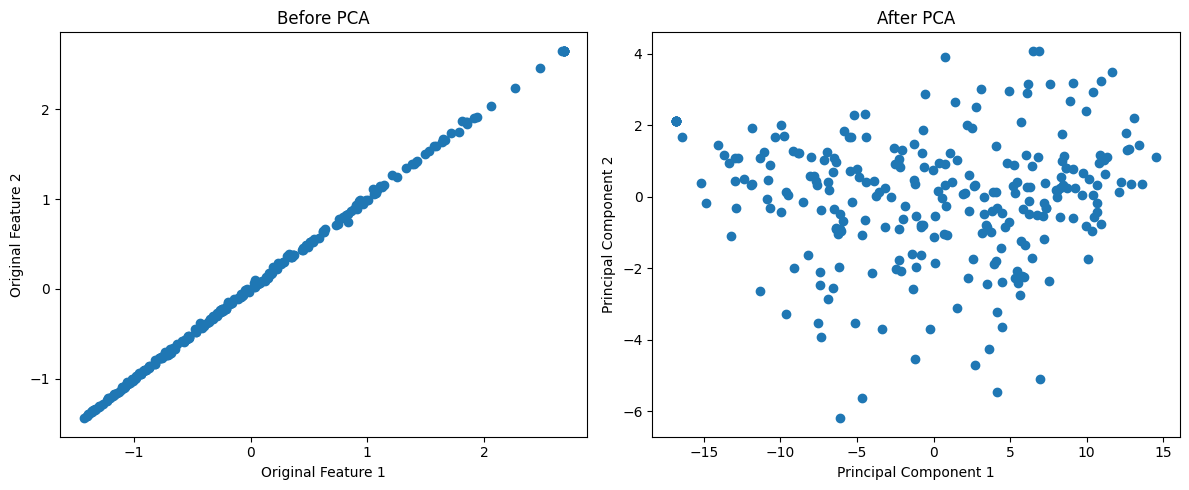

In [12]:
# Step 8: Visualize Before and After PCA

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))


# Plot original data using first two standardized features
plt.subplot(1, 2, 1)
plt.scatter(standardized_data[:, 0], standardized_data[:, 1])
plt.title("Before PCA")
plt.xlabel("Original Feature 1")
plt.ylabel("Original Feature 2")

# Plot reduced data after PCA
plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1])
plt.title("After PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()



Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. On the left side , the data forms a diagonal line meaning the first 2 features are highly collinear and portray the most redundancy .
On the right side PC1 was plotted to show the highest variance on the x axis next to PC2 reducing the correlation between the 2 features by a significant amount meaning much of the useful information is concentrated in the first principle component

2.  For the principle components , I took the 2 components because thw first 2 account for 98% of the data which is more than enough . Keeping more components
increases the complexity without giving much extra information.
The trade-off is that reducing to 2 components we massively simplify the dataset for easier computation but lose 1.2% of the data

3. The first two principle components account for 98.79% of the useful information. trading off the 1.21% loses small variations and minor relationships within the data but ultimately worth the simplicity and ease of visualisation gotten from the first 2 principle components